# Supply Chain & Demand Intelligence Platform
## Exploratory Data Analysis

This notebook explores the cleaned supply-chain dataset to identify
patterns, relationships, operational issues, and business opportunities.

The analysis is structured around four management questions:

1. What is happening?
2. Why is it happening?
3. What is likely to happen next?
4. What decisions should management consider?

The analysis focuses on:

- Revenue and profitability
- Customer and order performance
- Product and category performance
- Geographic performance
- Logistics and delivery performance
- Time-based trends
- Demand patterns
- Potential outliers and unusual behavior

### Analytical Principle

Every analysis should answer a meaningful business question.
Charts are used to support interpretation rather than as an end in themselves.

### Dataset Grain

The cleaned dataset is at the **order-item level**.

Therefore:

- Row count does not represent the number of orders.
- Order-level metrics should use unique `Order Id`.
- Customer-level metrics should use unique `Customer Id`.
- Order-item metrics should use unique `Order Item Id`.

## 1. Setup

We begin by loading the cleaned dataset and importing the libraries
required for exploratory analysis.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [4]:
file_path = "../data/processed/supply_chain_cleaned.csv"

df = pd.read_csv(
    file_path,
    parse_dates=["order date (DateOrders)", "shipping date (DateOrders)"]
)

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Id,Customer Segment,Customer State,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,order date (DateOrders),Order Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Card Id,Product Image,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,20755,Consumer,PR,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,2018-01-31 22:56:00,77202,13.11,0.04,180517,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,1360,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,19492,Consumer,PR,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,2018-01-13 12:27:00,75939,16.39,0.05,179254,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,1360,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,19491,Consumer,CA,"95,125.00",2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,2018-01-13 12:06:00,75938,18.03,0.06,179253,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,1360,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,19490,Home Office,CA,"90,027.00",2,Fitness,34.13,-118.29,Pacific Asia,Townsville,Australia,2018-01-13 11:45:00,75937,22.94,0.07,179252,0.08,1,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,1360,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,19489,Corporate,PR,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Townsville,Australia,2018-01-13 11:24:00,75936,29.50,0.09,179251,0.45,1,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,1360,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [5]:
print("Dataset shape:", df.shape)

print("\nUnique entities:")
print("Orders:", df["Order Id"].nunique())
print("Customers:", df["Customer Id"].nunique())
print("Order Items:", df["Order Item Id"].nunique())
print("Products:", df["Product Name"].nunique())
print("Categories:", df["Category Name"].nunique())

Dataset shape: (180519, 40)

Unique entities:
Orders: 65752
Customers: 20652
Order Items: 180519
Products: 118
Categories: 50


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  str           
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Sales per customer             180519 non-null  float64       
 4   Delivery Status                180519 non-null  str           
 5   Late_delivery_risk             180519 non-null  int64         
 6   Category Id                    180519 non-null  int64         
 7   Category Name                  180519 non-null  str           
 8   Customer City                  180519 non-null  str           
 9   Customer Country               180519 non-null  str           
 10  Customer Id                    180519 non-null  int64         
 11  Customer Se

## 3. Revenue & Profitability

This section evaluates the financial performance of the supply chain
business using revenue, discounts, profitability, and order-level metrics.

The analysis distinguishes between gross sales, net sales, and the
source-provided profit measure.

Key questions:

- How much revenue does the business generate?
- How profitable is that revenue?
- How much value is being given away through discounts?
- What is the average value of an order?
- Does strong sales performance translate into strong profitability?

In [7]:
total_gross_sales = df["Sales"].sum()
total_net_sales = df["Order Item Total"].sum()
total_discount = df["Order Item Discount"].sum()
total_profit = df["Order Profit Per Order"].sum()

total_orders = df["Order Id"].nunique()
total_customers = df["Customer Id"].nunique()
total_order_items = df["Order Item Id"].nunique()
total_units = df["Order Item Quantity"].sum()

profit_margin = total_profit / total_net_sales
average_discount_rate = df["Order Item Discount Rate"].mean()

order_values = df.groupby("Order Id")["Order Item Total"].sum()
average_order_value = order_values.mean()

print(f"Gross Sales:        ${total_gross_sales:,.2f}")
print(f"Net Sales:          ${total_net_sales:,.2f}")
print(f"Total Discount:     ${total_discount:,.2f}")
print(f"Total Profit:       ${total_profit:,.2f}")
print(f"Profit Margin:      {profit_margin:.2%}")
print(f"Average Discount:   {average_discount_rate:.2%}")
print(f"Orders:             {total_orders:,}")
print(f"Customers:          {total_customers:,}")
print(f"Order Items:        {total_order_items:,}")
print(f"Units Sold:         {total_units:,}")
print(f"Average Order Value:${average_order_value:,.2f}")

Gross Sales:        $36,784,735.01
Net Sales:          $33,054,402.38
Total Discount:     $3,730,378.40
Total Profit:       $3,966,902.97
Profit Margin:      12.00%
Average Discount:   10.17%
Orders:             65,752
Customers:          20,652
Order Items:        180,519
Units Sold:         384,079
Average Order Value:$502.71


In [8]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Gross Sales",
        "Net Sales",
        "Total Discount",
        "Total Profit",
        "Profit Margin",
        "Average Discount Rate",
        "Orders",
        "Customers",
        "Order Items",
        "Units Sold",
        "Average Order Value"
    ],
    "Value": [
        total_gross_sales,
        total_net_sales,
        total_discount,
        total_profit,
        profit_margin,
        average_discount_rate,
        total_orders,
        total_customers,
        total_order_items,
        total_units,
        average_order_value
    ]
})

kpi_summary

,KPI,Value
0,Gross Sales,"36,784,735.01"
1,Net Sales,"33,054,402.38"
2,Total Discount,"3,730,378.40"
3,Total Profit,"3,966,902.97"
4,Profit Margin,0.12
5,Average Discount Rate,0.10
6,Orders,"65,752.00"
7,Customers,"20,652.00"
8,Order Items,"180,519.00"
9,Units Sold,"384,079.00"


### 3.1 Category Revenue & Profitability

The overall business KPIs provide a high-level view, but they do not
show where revenue and profit are being generated.

This analysis compares product categories using:

- Gross sales
- Net sales
- Discounts
- Profit
- Profit margin
- Units sold

The objective is to identify categories that generate strong financial
performance as well as categories where high sales may not translate
into strong profitability.

In [9]:
category_performance = (
    df.groupby("Category Name")
      .agg(
          Gross_Sales=("Sales", "sum"),
          Net_Sales=("Order Item Total", "sum"),
          Discount=("Order Item Discount", "sum"),
          Profit=("Order Profit Per Order", "sum"),
          Units_Sold=("Order Item Quantity", "sum"),
          Order_Items=("Order Item Id", "nunique")
      )
      .reset_index()
)

category_performance["Profit_Margin"] = (
    category_performance["Profit"] /
    category_performance["Net_Sales"]
)

category_performance["Discount_Rate"] = (
    category_performance["Discount"] /
    category_performance["Gross_Sales"]
)

category_performance.sort_values(
    "Net_Sales",
    ascending=False
)

,Category Name,Gross_Sales,Net_Sales,Discount,Profit,Units_Sold,Order_Items,Profit_Margin,Discount_Rate
18,Fishing,"6,929,653.69","6,226,935.29","702,728.00","756,220.77",17325,17325,0.12,0.10
12,Cleats,"4,431,942.78","3,982,856.50","449,091.67","494,636.92",73734,24551,0.12,0.10
9,Camping & Hiking,"4,118,425.57","3,700,783.63","417,649.50","427,455.57",13729,13729,0.12,0.10
10,Cardio Equipment,"3,694,843.20","3,320,250.70","374,595.19","383,011.10",37587,12487,0.12,0.10
47,Women's Apparel,"3,147,800.00","2,828,708.50","319,091.50","350,421.03",62956,21035,0.12,0.10
46,Water Sports,"3,113,844.68","2,798,044.18","315,800.50","325,146.96",15540,15540,0.12,0.10
34,Men's Footwear,"2,891,757.66","2,598,494.42","293,263.10","311,902.82",22246,22246,0.12,0.10
30,Indoor/Outdoor Games,"2,888,993.91","2,596,454.02","292,550.63","318,451.43",57803,19298,0.12,0.10
38,Shop By Sport,"1,309,522.04","1,177,185.63","132,338.73","129,813.96",32726,10984,0.11,0.10
13,Computers,"663,000.00","595,395.00","67,605.00","69,656.81",442,442,0.12,0.10


In [10]:
category_performance.sort_values(
    "Profit",
    ascending=False
).head(10)

,Category Name,Gross_Sales,Net_Sales,Discount,Profit,Units_Sold,Order_Items,Profit_Margin,Discount_Rate
18,Fishing,"6,929,653.69","6,226,935.29","702,728.00","756,220.77",17325,17325,0.12,0.10
12,Cleats,"4,431,942.78","3,982,856.50","449,091.67","494,636.92",73734,24551,0.12,0.10
9,Camping & Hiking,"4,118,425.57","3,700,783.63","417,649.50","427,455.57",13729,13729,0.12,0.10
10,Cardio Equipment,"3,694,843.20","3,320,250.70","374,595.19","383,011.10",37587,12487,0.12,0.10
47,Women's Apparel,"3,147,800.00","2,828,708.50","319,091.50","350,421.03",62956,21035,0.12,0.10
46,Water Sports,"3,113,844.68","2,798,044.18","315,800.50","325,146.96",15540,15540,0.12,0.10
30,Indoor/Outdoor Games,"2,888,993.91","2,596,454.02","292,550.63","318,451.43",57803,19298,0.12,0.10
34,Men's Footwear,"2,891,757.66","2,598,494.42","293,263.10","311,902.82",22246,22246,0.12,0.10
38,Shop By Sport,"1,309,522.04","1,177,185.63","132,338.73","129,813.96",32726,10984,0.11,0.10
13,Computers,"663,000.00","595,395.00","67,605.00","69,656.81",442,442,0.12,0.10


In [11]:
category_performance.sort_values(
    "Profit",
    ascending=True
).head(10)

,Category Name,Gross_Sales,Net_Sales,Discount,Profit,Units_Sold,Order_Items,Profit_Margin,Discount_Rate
41,Strength Training,"54,895.53","48,813.84","6,081.72",332.31,111,111,0.01,0.11
7,CDs,"3,059.59","2,750.03",309.56,383.85,271,271,0.14,0.10
1,As Seen on TV!,"20,597.94","18,519.61","2,078.37",714.43,206,68,0.04,0.10
5,Books,"12,587.40","11,303.42","1,283.98",883.01,405,405,0.08,0.10
43,Toys,"6,104.66","5,485.68",619.27,900.71,529,529,0.16,0.10
2,Baby,"12,229.56","10,957.40","1,272.16","1,525.03",207,207,0.14,0.10
23,Golf Bags & Carts,"10,369.39","9,403.79",965.60,"1,810.07",61,61,0.19,0.09
4,Basketball,"27,099.33","24,705.33","2,394.00","1,845.67",67,67,0.07,0.09
33,Men's Clothing,"43,856.80","39,365.71","4,491.21","2,006.04",208,208,0.05,0.10
45,Video Games,"33,310.50","29,919.20","3,392.69","2,717.52",838,838,0.09,0.10


In [12]:
category_performance.sort_values(
    "Profit_Margin",
    ascending=False
)

,Category Name,Gross_Sales,Net_Sales,Discount,Profit,Units_Sold,Order_Items,Profit_Margin,Discount_Rate
23,Golf Bags & Carts,"10,369.39","9,403.79",965.60,"1,810.07",61,61,0.19,0.09
19,Fitness Accessories,"35,601.44","31,751.36","3,850.16","5,258.39",856,309,0.17,0.11
43,Toys,"6,104.66","5,485.68",619.27,900.71,529,529,0.16,0.10
39,Soccer,"26,477.05","23,909.95","2,567.12","3,901.95",295,138,0.16,0.10
48,Women's Clothing,"140,283.00","126,006.93","14,276.44","19,102.85",650,650,0.15,0.10
3,Baseball & Softball,"94,057.15","84,367.27","9,689.99","12,762.13",1785,632,0.15,0.10
20,Garden,"257,768.73","231,765.46","26,003.52","33,443.01",484,484,0.14,0.10
42,Tennis & Racquet,"44,585.09","40,077.81","4,507.39","5,747.98",991,328,0.14,0.10
36,Music,"113,122.10","101,687.29","11,435.05","14,436.32",434,434,0.14,0.10
7,CDs,"3,059.59","2,750.03",309.56,383.85,271,271,0.14,0.10


### 3.2 Revenue Scale vs Profitability

A category's absolute revenue and profitability should be evaluated
together.

A high-revenue category with weak margins may require a different
management response than a low-revenue category with strong margins.

This analysis therefore compares:

- Net sales
- Profit margin
- Absolute profit

The objective is to identify strong performers, high-revenue/low-margin
categories, and potentially attractive but small categories.

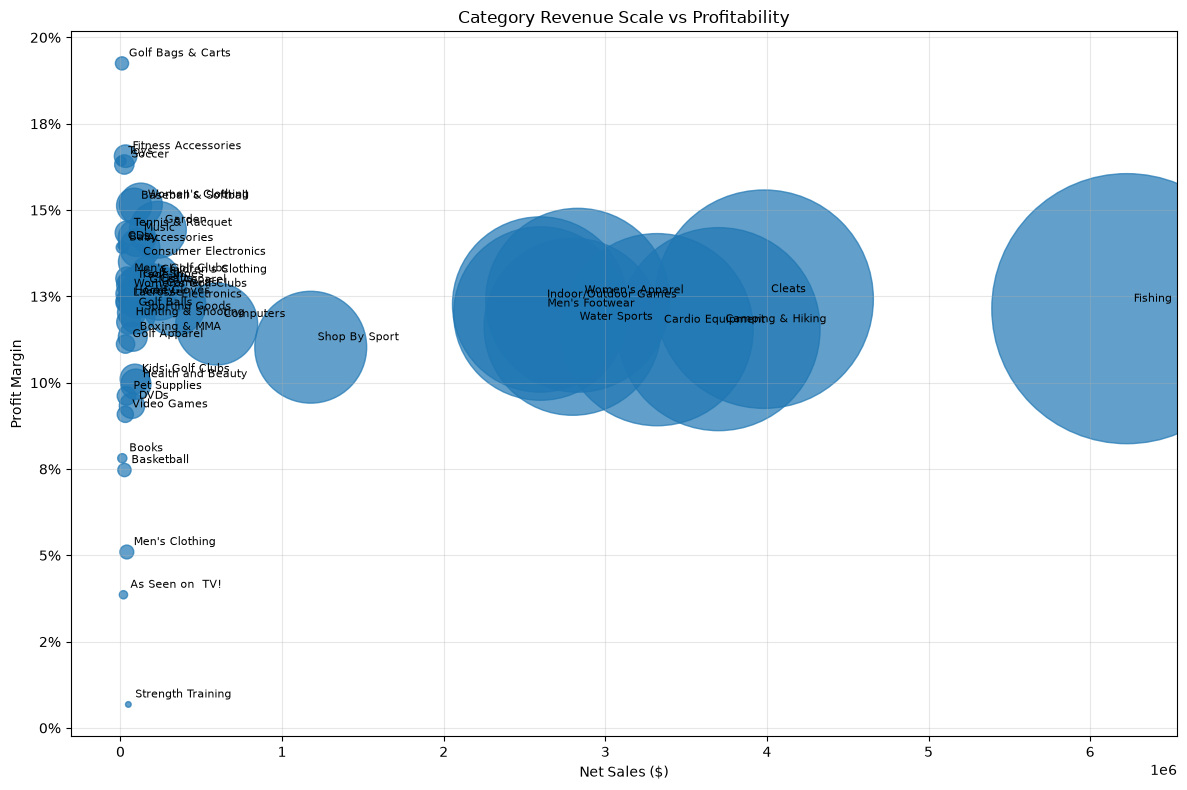

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    category_performance["Net_Sales"],
    category_performance["Profit_Margin"],
    s=category_performance["Profit"] / 20,
    alpha=0.7
)

for _, row in category_performance.iterrows():
    ax.annotate(
        row["Category Name"],
        (row["Net_Sales"], row["Profit_Margin"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title("Category Revenue Scale vs Profitability")
ax.set_xlabel("Net Sales ($)")
ax.set_ylabel("Profit Margin")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

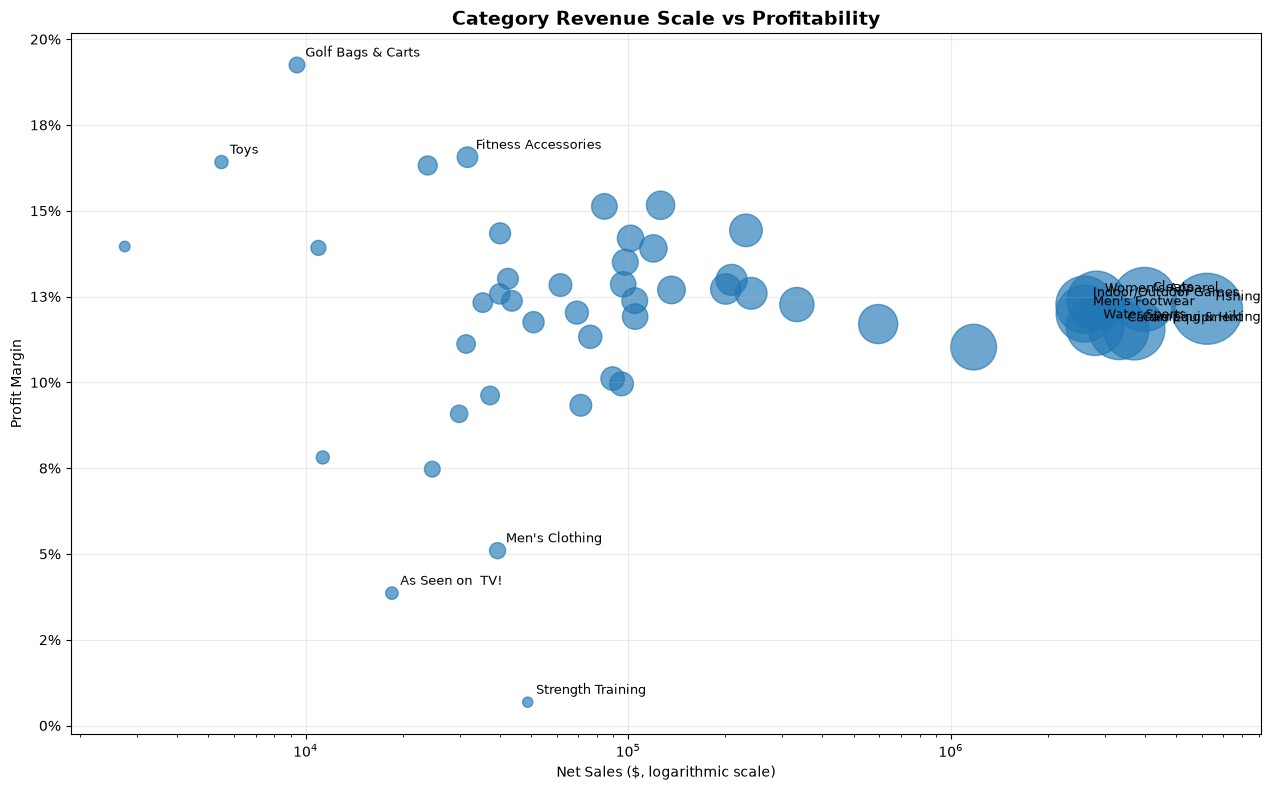

In [14]:
fig, ax = plt.subplots(figsize=(13, 8))

bubble_sizes = np.sqrt(category_performance["Profit"]) * 3

ax.scatter(
    category_performance["Net_Sales"],
    category_performance["Profit_Margin"],
    s=bubble_sizes,
    alpha=0.65
)

# Label only strategically important categories
important_categories = pd.concat([
    category_performance.nlargest(8, "Net_Sales"),
    category_performance.nsmallest(3, "Profit_Margin"),
    category_performance.nlargest(3, "Profit_Margin")
]).drop_duplicates()

for _, row in important_categories.iterrows():
    ax.annotate(
        row["Category Name"],
        (row["Net_Sales"], row["Profit_Margin"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

ax.set_xscale("log")

ax.set_title(
    "Category Revenue Scale vs Profitability",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Net Sales ($, logarithmic scale)")
ax.set_ylabel("Profit Margin")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 3.3 Discounting vs Profitability

Discounting can increase sales volume but may reduce profitability.

This analysis investigates whether differences in category discount rates
are associated with differences in profit margins.

The objective is not to assume that discounts cause lower profitability,
but to determine whether a relationship exists in the observed data.

In [15]:
discount_profitability = category_performance[
    [
        "Category Name",
        "Discount_Rate",
        "Profit_Margin",
        "Net_Sales",
        "Profit"
    ]
].copy()

discount_profitability.sort_values(
    "Discount_Rate",
    ascending=False
)

,Category Name,Discount_Rate,Profit_Margin,Net_Sales,Profit
41,Strength Training,0.11,0.01,"48,813.84",332.31
19,Fitness Accessories,0.11,0.17,"31,751.36","5,258.39"
26,Golf Shoes,0.11,0.13,"96,506.47","12,406.07"
29,Hunting & Shooting,0.11,0.12,"50,878.91","5,980.00"
6,Boxing & MMA,0.10,0.11,"76,286.72","8,641.37"
0,Accessories,0.10,0.14,"119,712.55","16,643.52"
2,Baby,0.10,0.14,"10,957.40","1,525.03"
3,Baseball & Softball,0.10,0.15,"84,367.27","12,762.13"
44,Trade-In,0.10,0.13,"61,667.54","7,915.37"
32,Lacrosse,0.10,0.12,"35,415.93","4,364.29"


In [17]:
print(
    "Pearson correlation:",
    discount_profitability["Discount_Rate"].corr(
        discount_profitability["Profit_Margin"]
    )
)

print(
    "Spearman correlation:",
    discount_profitability["Discount_Rate"].corr(
        discount_profitability["Profit_Margin"],
        method="spearman"
    )
)


Pearson correlation: -0.14635553524699108
Spearman correlation: 0.0114765906362545


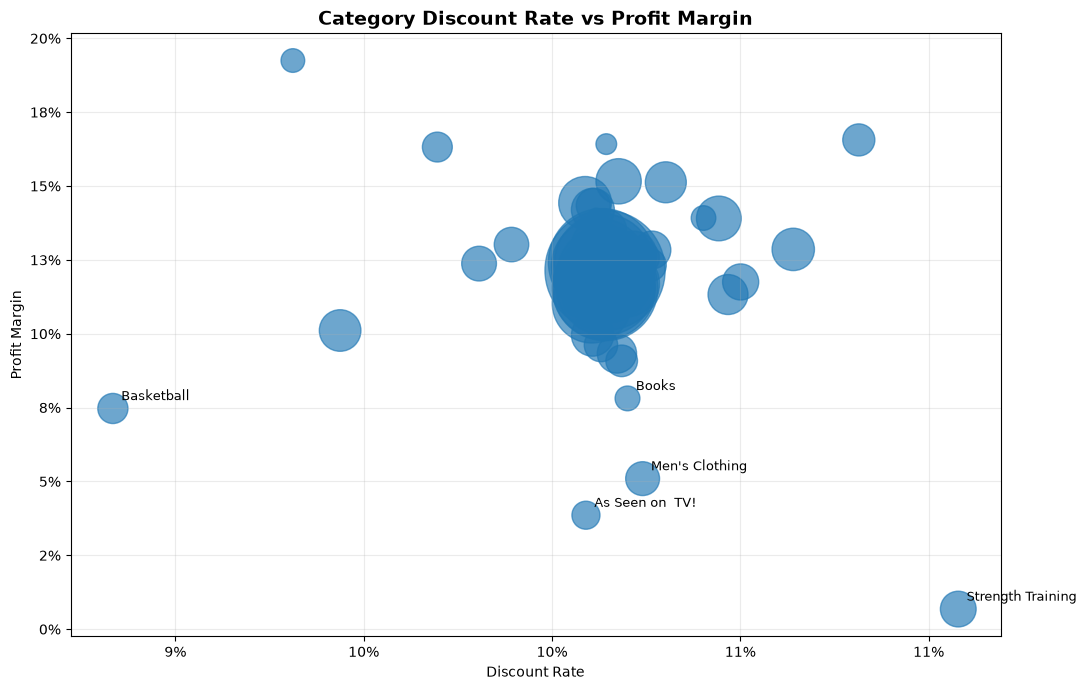

In [18]:
fig, ax = plt.subplots(figsize=(11, 7))

bubble_sizes = np.sqrt(
    discount_profitability["Net_Sales"]
) * 3

ax.scatter(
    discount_profitability["Discount_Rate"],
    discount_profitability["Profit_Margin"],
    s=bubble_sizes,
    alpha=0.65
)

low_margin_categories = discount_profitability.nsmallest(
    5,
    "Profit_Margin"
)

for _, row in low_margin_categories.iterrows():
    ax.annotate(
        row["Category Name"],
        (row["Discount_Rate"], row["Profit_Margin"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

ax.set_title(
    "Category Discount Rate vs Profit Margin",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Discount Rate")
ax.set_ylabel("Profit Margin")

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### 3.4 Product-Level Performance

Category-level analysis can hide substantial differences between
individual products.

This analysis evaluates product-level revenue, profitability,
sales volume, and margins to identify:

- Top revenue-generating products
- Top profit-generating products
- High-volume products
- Low-margin products
- Products that may require further investigation

The objective is to determine whether category performance is
concentrated among a small number of products.

In [19]:
product_performance = (
    df.groupby(["Product Card Id", "Product Name"])
      .agg(
          Gross_Sales=("Sales", "sum"),
          Net_Sales=("Order Item Total", "sum"),
          Discount=("Order Item Discount", "sum"),
          Profit=("Order Profit Per Order", "sum"),
          Units_Sold=("Order Item Quantity", "sum"),
          Order_Items=("Order Item Id", "nunique")
      )
      .reset_index()
)

product_performance["Profit_Margin"] = (
    product_performance["Profit"] /
    product_performance["Net_Sales"]
)

product_performance["Discount_Rate"] = (
    product_performance["Discount"] /
    product_performance["Gross_Sales"]
)

print("Number of products:", len(product_performance))

product_performance.head()

Number of products: 118


,Product Card Id,Product Name,Gross_Sales,Net_Sales,Discount,Profit,Units_Sold,Order_Items,Profit_Margin,Discount_Rate
0,19,Nike Men's Fingertrap Max Training Shoe,"7,999.36","7,256.88",742.48,602.38,64,64,0.08,0.09
1,24,Elevation Training Mask 2.0,"18,477.69","16,653.07","1,824.64","3,299.57",231,74,0.20,0.10
2,35,adidas Brazuca 2014 Official Match Ball,"10,399.35","9,386.55","1,012.80","1,642.73",65,65,0.18,0.10
3,37,adidas Kids' F5 Messi FG Soccer Cleat,"27,327.19","24,626.51","2,700.72","2,906.33",781,262,0.12,0.10
4,44,adidas Men's F10 Messi TRX FG Soccer Cleat,"56,330.61","50,354.21","5,976.47","8,213.07",939,305,0.16,0.11


In [20]:
product_performance.sort_values(
    "Net_Sales",
    ascending=False
).head(10)

,Product Card Id,Product Name,Gross_Sales,Net_Sales,Discount,Profit,Units_Sold,Order_Items,Profit_Margin,Discount_Rate
96,1004,Field & Stream Sportsman 16 Gun Fire Safe,"6,929,653.69","6,226,935.29","702,728.00","756,220.77",17325,17325,0.12,0.10
35,365,Perfect Fitness Perfect Rip Deck,"4,421,143.14","3,973,180.36","447,968.17","493,828.30",73698,24515,0.12,0.10
92,957,Diamondback Women's Serene Classic Comfort Bi,"4,118,425.57","3,700,783.63","417,649.50","427,455.57",13729,13729,0.12,0.10
15,191,Nike Men's Free 5.0+ Running Shoe,"3,667,633.20","3,295,693.30","371,942.59","379,915.82",36680,12169,0.12,0.10
37,502,Nike Men's Dri-FIT Victory Golf Polo,"3,147,800.00","2,828,708.50","319,091.50","350,421.03",62956,21035,0.12,0.10
99,1073,Pelican Sunstream 100 Kayak,"3,099,845.09","2,785,518.09","314,327.00","324,076.37",15500,15500,0.12,0.10
36,403,Nike Men's CJ Elite 2 TD Football Cleat,"2,891,757.66","2,598,494.42","293,263.10","311,902.82",22246,22246,0.12,0.10
97,1014,O'Brien Men's Neoprene Life Vest,"2,888,993.91","2,596,454.02","292,550.63","318,451.43",57803,19298,0.12,0.10
44,627,Under Armour Girls' Toddler Spine Surge Runni,"1,269,082.67","1,140,770.96","128,314.03","126,278.51",31735,10617,0.11,0.10
105,1351,Dell Laptop,"663,000.00","595,395.00","67,605.00","69,656.81",442,442,0.12,0.10


In [21]:
product_performance.sort_values(
    "Profit",
    ascending=False
).head(10)

,Product Card Id,Product Name,Gross_Sales,Net_Sales,Discount,Profit,Units_Sold,Order_Items,Profit_Margin,Discount_Rate
96,1004,Field & Stream Sportsman 16 Gun Fire Safe,"6,929,653.69","6,226,935.29","702,728.00","756,220.77",17325,17325,0.12,0.10
35,365,Perfect Fitness Perfect Rip Deck,"4,421,143.14","3,973,180.36","447,968.17","493,828.30",73698,24515,0.12,0.10
92,957,Diamondback Women's Serene Classic Comfort Bi,"4,118,425.57","3,700,783.63","417,649.50","427,455.57",13729,13729,0.12,0.10
15,191,Nike Men's Free 5.0+ Running Shoe,"3,667,633.20","3,295,693.30","371,942.59","379,915.82",36680,12169,0.12,0.10
37,502,Nike Men's Dri-FIT Victory Golf Polo,"3,147,800.00","2,828,708.50","319,091.50","350,421.03",62956,21035,0.12,0.10
99,1073,Pelican Sunstream 100 Kayak,"3,099,845.09","2,785,518.09","314,327.00","324,076.37",15500,15500,0.12,0.10
97,1014,O'Brien Men's Neoprene Life Vest,"2,888,993.91","2,596,454.02","292,550.63","318,451.43",57803,19298,0.12,0.10
36,403,Nike Men's CJ Elite 2 TD Football Cleat,"2,891,757.66","2,598,494.42","293,263.10","311,902.82",22246,22246,0.12,0.10
44,627,Under Armour Girls' Toddler Spine Surge Runni,"1,269,082.67","1,140,770.96","128,314.03","126,278.51",31735,10617,0.11,0.10
105,1351,Dell Laptop,"663,000.00","595,395.00","67,605.00","69,656.81",442,442,0.12,0.10


In [22]:
product_performance.sort_values(
    "Profit_Margin",
    ascending=True
).head(10)

,Product Card Id,Product Name,Gross_Sales,Net_Sales,Discount,Profit,Units_Sold,Order_Items,Profit_Margin,Discount_Rate
82,860,Bushnell Pro X7 Jolt Slope Rangefinder,"6,599.89","6,062.89",537.00,-255.95,11,11,-0.04,0.08
17,208,SOLE E35 Elliptical,"29,999.85","26,409.85","3,590.00",-965.12,15,15,-0.04,0.12
6,60,SOLE E25 Elliptical,"9,999.90","9,414.90",585.00,-169.56,10,10,-0.02,0.06
16,203,GoPro HERO3+ Black Edition Camera,"12,799.68","11,601.68","1,198.00",245.63,32,32,0.02,0.09
29,303,Garmin Forerunner 910XT GPS Watch,"13,999.65","12,593.65","1,406.00",391.13,35,35,0.03,0.10
7,61,Diamondback Girls' Clarity 24 Hybrid Bike 201,"8,399.72","7,624.22",775.50,284.42,28,28,0.04,0.09
33,359,Nike Men's Free TR 5.0 TB Training Shoe,"20,597.94","18,519.61","2,078.37",714.43,206,68,0.04,0.10
54,705,Cleveland Golf Women's 588 RTX CB Satin Chrom,"8,399.30","7,538.30",861.00,370.61,70,70,0.05,0.10
111,1357,Men's gala suit,"43,856.80","39,365.71","4,491.21","2,006.04",208,208,0.05,0.10
81,858,GolfBuddy VT3 GPS Watch,"11,799.41","10,637.41","1,162.00",569.02,59,59,0.05,0.10


### 3.5 Product Revenue & Profit Concentration

The product-level analysis indicates that a small number of products may
account for a substantial proportion of total revenue and profit.

This analysis quantifies that concentration by calculating the share of
total net sales and profit contributed by the top products.

It also identifies products generating negative profit.

Key questions:

- What percentage of revenue comes from the top 1, 5, and 10 products?
- What percentage of profit comes from the top 1, 5, and 10 products?
- How many products generate negative profit?
- Are the business's financial results highly dependent on a small
  number of products?

In [23]:
product_by_revenue = product_performance.sort_values(
    "Net_Sales",
    ascending=False
).copy()

total_product_revenue = product_by_revenue["Net_Sales"].sum()

for n in [1, 5, 10]:
    share = (
        product_by_revenue.head(n)["Net_Sales"].sum()
        / total_product_revenue
    )
    
    print(f"Top {n} products revenue share: {share:.2%}")

Top 1 products revenue share: 18.84%
Top 5 products revenue share: 60.58%
Top 10 products revenue share: 89.98%


In [24]:
product_by_profit = product_performance.sort_values(
    "Profit",
    ascending=False
).copy()

total_product_profit = product_by_profit["Profit"].sum()

for n in [1, 5, 10]:
    share = (
        product_by_profit.head(n)["Profit"].sum()
        / total_product_profit
    )
    
    print(f"Top {n} products profit share: {share:.2%}")

Top 1 products profit share: 19.06%
Top 5 products profit share: 60.70%
Top 10 products profit share: 89.70%


In [25]:
negative_profit_products = product_performance[
    product_performance["Profit"] < 0
].copy()

print(
    "Products with negative profit:",
    len(negative_profit_products)
)

print(
    "Share of products with negative profit:",
    len(negative_profit_products) / len(product_performance)
)

negative_profit_products.sort_values(
    "Profit",
    ascending=True
)

Products with negative profit: 3
Share of products with negative profit: 0.025423728813559324


,Product Card Id,Product Name,Gross_Sales,Net_Sales,Discount,Profit,Units_Sold,Order_Items,Profit_Margin,Discount_Rate
17,208,SOLE E35 Elliptical,"29,999.85","26,409.85","3,590.00",-965.12,15,15,-0.04,0.12
82,860,Bushnell Pro X7 Jolt Slope Rangefinder,"6,599.89","6,062.89",537.00,-255.95,11,11,-0.04,0.08
6,60,SOLE E25 Elliptical,"9,999.90","9,414.90",585.00,-169.56,10,10,-0.02,0.06


### 3.6 Product Revenue Concentration

The product-level analysis shows that revenue and profit are highly
concentrated among a small number of products.

A Pareto-style analysis is used to visualize the cumulative contribution
of products ranked by net sales.

This helps quantify the degree of product concentration and identify
the point at which the majority of business revenue is generated.

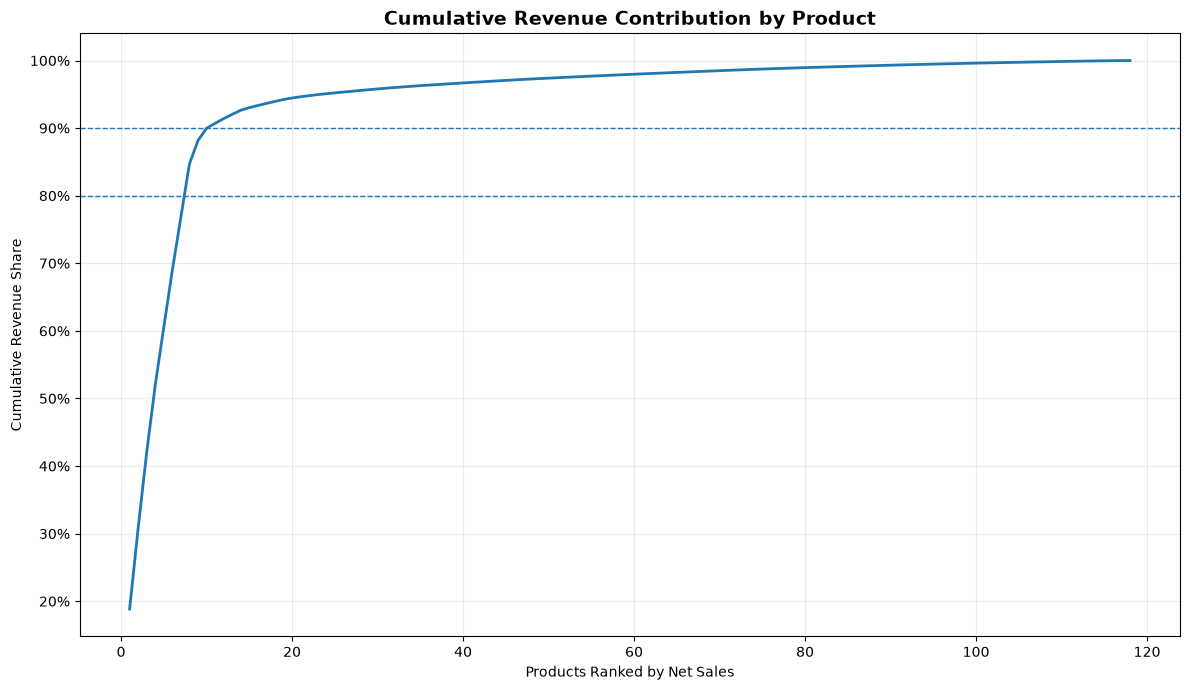

In [26]:
pareto_products = product_performance.sort_values(
    "Net_Sales",
    ascending=False
).reset_index(drop=True)

pareto_products["Cumulative_Revenue_Share"] = (
    pareto_products["Net_Sales"].cumsum()
    / pareto_products["Net_Sales"].sum()
)

product_rank = np.arange(1, len(pareto_products) + 1)

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    product_rank,
    pareto_products["Cumulative_Revenue_Share"],
    linewidth=2
)

ax.axhline(
    0.80,
    linestyle="--",
    linewidth=1
)

ax.axhline(
    0.90,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Cumulative Revenue Contribution by Product",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Products Ranked by Net Sales")
ax.set_ylabel("Cumulative Revenue Share")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [27]:
for threshold in [0.50, 0.80, 0.90, 0.95]:
    products_needed = (
        pareto_products["Cumulative_Revenue_Share"] >= threshold
    ).idxmax() + 1

    print(
        f"Products required for {threshold:.0%} of revenue: "
        f"{products_needed}"
    )

Products required for 50% of revenue: 4
Products required for 80% of revenue: 8
Products required for 90% of revenue: 11
Products required for 95% of revenue: 24


### 3.7 Time-Based Sales & Demand Trends

Understanding how demand changes over time is essential for supply-chain
planning.

This analysis examines sales and order activity across the observed
period to identify:

- Overall revenue trends
- Changes in order volume
- Seasonal patterns
- Periods of unusually high or low demand

The analysis will use order-level metrics where appropriate to avoid
double-counting orders across order-item rows.

In [28]:
print("Order date range:")
print("Start:", df["order date (DateOrders)"].min())
print("End:", df["order date (DateOrders)"].max())

Order date range:
Start: 2015-01-01 00:00:00
End: 2018-01-31 23:38:00


In [29]:
monthly_performance = (
    df.assign(
        Month=df["order date (DateOrders)"].dt.to_period("M")
    )
    .groupby("Month")
    .agg(
        Net_Sales=("Order Item Total", "sum"),
        Profit=("Order Profit Per Order", "sum"),
        Order_Items=("Order Item Id", "nunique"),
        Units_Sold=("Order Item Quantity", "sum")
    )
    .reset_index()
)

monthly_performance["Month"] = (
    monthly_performance["Month"].dt.to_timestamp()
)

monthly_performance["Profit_Margin"] = (
    monthly_performance["Profit"] /
    monthly_performance["Net_Sales"]
)

monthly_performance

,Month,Net_Sales,Profit,Order_Items,Units_Sold,Profit_Margin
0,2015-01-01,"945,382.16","111,660.74",5322,11854,0.12
1,2015-02-01,"833,012.43","99,140.66",4729,10438,0.12
2,2015-03-01,"944,050.11","113,778.21",5362,12062,0.12
3,2015-04-01,"912,004.40","108,083.68",5126,11287,0.12
4,2015-05-01,"943,939.77","112,147.90",5357,11902,0.12
5,2015-06-01,"920,242.06","110,147.16",5134,11203,0.12
6,2015-07-01,"932,936.79","115,624.06",5299,11800,0.12
7,2015-08-01,"925,192.87","117,979.77",5273,11612,0.13
8,2015-09-01,"914,522.37","113,467.94",5140,11366,0.12
9,2015-10-01,"943,131.10","101,757.87",5302,11703,0.11


In [30]:
monthly_orders = (
    df.assign(
        Month=df["order date (DateOrders)"].dt.to_period("M")
    )
    .groupby("Month")["Order Id"]
    .nunique()
    .reset_index(name="Orders")
)

monthly_orders["Month"] = (
    monthly_orders["Month"].dt.to_timestamp()
)

monthly_performance = monthly_performance.merge(
    monthly_orders,
    on="Month",
    how="left"
)

monthly_performance

,Month,Net_Sales,Profit,Order_Items,Units_Sold,Profit_Margin,Orders
0,2015-01-01,"945,382.16","111,660.74",5322,11854,0.12,1787
1,2015-02-01,"833,012.43","99,140.66",4729,10438,0.12,1585
2,2015-03-01,"944,050.11","113,778.21",5362,12062,0.12,1781
3,2015-04-01,"912,004.40","108,083.68",5126,11287,0.12,1710
4,2015-05-01,"943,939.77","112,147.90",5357,11902,0.12,1776
5,2015-06-01,"920,242.06","110,147.16",5134,11203,0.12,1725
6,2015-07-01,"932,936.79","115,624.06",5299,11800,0.12,1763
7,2015-08-01,"925,192.87","117,979.77",5273,11612,0.13,1762
8,2015-09-01,"914,522.37","113,467.94",5140,11366,0.12,1706
9,2015-10-01,"943,131.10","101,757.87",5302,11703,0.11,1775


### 3.7.1 Monthly Order Composition

The monthly trend reveals a sharp structural change beginning in
October 2017. While order counts remain relatively high, units sold
and order-item counts decline substantially.

Before interpreting this as a genuine demand decline, the underlying
order composition is investigated to determine whether the change is
driven by purchasing behavior, product mix, or a change in the
underlying transaction structure.

In [31]:
monthly_performance["Units_per_Order"] = (
    monthly_performance["Units_Sold"] /
    monthly_performance["Orders"]
)

monthly_performance[
    [
        "Month",
        "Orders",
        "Units_Sold",
        "Units_per_Order",
        "Net_Sales",
        "Profit_Margin"
    ]
]

,Month,Orders,Units_Sold,Units_per_Order,Net_Sales,Profit_Margin
0,2015-01-01,1787,11854,6.63,"945,382.16",0.12
1,2015-02-01,1585,10438,6.59,"833,012.43",0.12
2,2015-03-01,1781,12062,6.77,"944,050.11",0.12
3,2015-04-01,1710,11287,6.60,"912,004.40",0.12
4,2015-05-01,1776,11902,6.70,"943,939.77",0.12
5,2015-06-01,1725,11203,6.49,"920,242.06",0.12
6,2015-07-01,1763,11800,6.69,"932,936.79",0.12
7,2015-08-01,1762,11612,6.59,"925,192.87",0.13
8,2015-09-01,1706,11366,6.66,"914,522.37",0.12
9,2015-10-01,1775,11703,6.59,"943,131.10",0.11


In [32]:
monthly_performance["AOV"] = (
    monthly_performance["Net_Sales"] /
    monthly_performance["Orders"]
)

monthly_performance[
    [
        "Month",
        "Orders",
        "Units_per_Order",
        "AOV"
    ]
]

,Month,Orders,Units_per_Order,AOV
0,2015-01-01,1787,6.63,529.03
1,2015-02-01,1585,6.59,525.56
2,2015-03-01,1781,6.77,530.07
3,2015-04-01,1710,6.60,533.34
4,2015-05-01,1776,6.70,531.50
5,2015-06-01,1725,6.49,533.47
6,2015-07-01,1763,6.69,529.18
7,2015-08-01,1762,6.59,525.08
8,2015-09-01,1706,6.66,536.06
9,2015-10-01,1775,6.59,531.34


In [33]:
pre_change = monthly_performance[
    monthly_performance["Month"] < "2017-10-01"
]

post_change = monthly_performance[
    monthly_performance["Month"] >= "2017-10-01"
]

print("BEFORE OCTOBER 2017")
print(
    "Average orders/month:",
    round(pre_change["Orders"].mean(), 0)
)
print(
    "Average units/order:",
    round(pre_change["Units_per_Order"].mean(), 2)
)
print(
    "Average AOV:",
    round(pre_change["AOV"].mean(), 2)
)

print("\nFROM OCTOBER 2017")
print(
    "Average orders/month:",
    round(post_change["Orders"].mean(), 0)
)
print(
    "Average units/order:",
    round(post_change["Units_per_Order"].mean(), 2)
)
print(
    "Average AOV:",
    round(post_change["AOV"].mean(), 2)
)

BEFORE OCTOBER 2017
Average orders/month: 1738.0
Average units/order: 6.54
Average AOV: 536.66

FROM OCTOBER 2017
Average orders/month: 2101.0
Average units/order: 1.05
Average AOV: 271.87


In [34]:
df.assign(
    Month=df["order date (DateOrders)"].dt.to_period("M")
).groupby(
    ["Month", "Order Status"]
).size().unstack(fill_value=0)

Order Status,CANCELED,CLOSED,COMPLETE,ON_HOLD,PAYMENT_REVIEW,PENDING,PENDING_PAYMENT,PROCESSING,SUSPECTED_FRAUD
Month,,,,,,,,,
2015-01,84,560,1760,270,50,646,1166,662,124
2015-02,127,566,1520,207,53,600,930,611,115
2015-03,115,632,1646,290,60,608,1214,677,120
2015-04,122,586,1658,350,76,566,1116,563,89
2015-05,134,575,1824,272,49,506,1171,690,136
2015-06,96,552,1701,267,36,567,1119,666,130
2015-07,73,632,1704,312,51,535,1204,686,102
2015-08,126,554,1790,313,56,560,1153,599,122
2015-09,92,622,1666,322,52,545,1138,581,122
